# Stage 6 Classifier Results Inspection

This notebook loads classifier validation outputs and gives quick sanity checks plus visual comparisons.

It expects artifacts produced by `scripts/03_run_classifiers.py` under:
- `results/classifier/<method>/scores.parquet`
- `results/classifier/<method>/meta.json`

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "results").exists() and (cwd / "scripts").exists():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "results").exists() and (cwd.parent / "scripts").exists():
        return cwd.parent
    raise FileNotFoundError(
        "Could not resolve repository root from current working directory. "
        "Open the notebook in the project workspace root or notebooks folder."
    )


REPO_ROOT = resolve_repo_root()
CLASSIFIER_RESULTS_DIR = REPO_ROOT / "results" / "classifier"

print(f"Repo root: {REPO_ROOT}")
print(f"Classifier results dir: {CLASSIFIER_RESULTS_DIR}")

Repo root: C:\Programmering\exjobb\MSc26_Proteomics
Classifier results dir: C:\Programmering\exjobb\MSc26_Proteomics\results\classifier


## Load Scores And Metadata

This cell discovers all methods with `scores.parquet` and combines them into one dataframe for comparison.

In [2]:
def load_classifier_results(base_dir: Path) -> tuple[pd.DataFrame, dict[str, dict]]:
    if not base_dir.exists():
        raise FileNotFoundError(f"Classifier results directory not found: {base_dir}")

    frames: list[pd.DataFrame] = []
    meta_by_method: dict[str, dict] = {}

    for method_dir in sorted(base_dir.iterdir()):
        if not method_dir.is_dir():
            continue

        scores_path = method_dir / "scores.parquet"
        meta_path = method_dir / "meta.json"
        if not scores_path.exists():
            continue

        method_name = method_dir.name
        df = pd.read_parquet(scores_path).copy()
        df["method"] = method_name
        df["k"] = df["k"].astype(str)
        frames.append(df)

        if meta_path.exists():
            meta_by_method[method_name] = json.loads(meta_path.read_text(encoding="utf-8"))

    if not frames:
        raise FileNotFoundError(
            f"No scores.parquet files found under: {base_dir}"
        )

    all_scores = pd.concat(frames, ignore_index=True)
    return all_scores, meta_by_method


scores, meta_by_method = load_classifier_results(CLASSIFIER_RESULTS_DIR)

print(f"Methods loaded: {sorted(scores['method'].unique().tolist())}")
print(f"Total rows: {len(scores):,}")
print(f"Columns: {scores.columns.tolist()}")

display(scores.head())

Methods loaded: ['random', 'ttest']
Total rows: 1,500
Columns: ['split_id', 'classifier', 'k', 'auc', 'aupr', 'n_features_actual', 'method']


,split_id,classifier,k,auc,aupr,n_features_actual,method
0,0,LogisticRegression,10,0.683389,0.483492,10,random
1,0,RandomForest,10,0.706800,0.283787,10,random
2,0,XGBoost,10,0.666667,0.268111,10,random
3,0,LogisticRegression,25,0.634337,0.501498,25,random
4,0,RandomForest,25,0.653289,0.304988,25,random


In [3]:
required_cols = {"split_id", "classifier", "k", "auc", "aupr", "n_features_actual", "method"}
missing_cols = required_cols.difference(scores.columns)
if missing_cols:
    raise ValueError(f"Missing expected columns: {sorted(missing_cols)}")

coverage = (
    scores.groupby("method", as_index=False)
    .agg(
        n_rows=("split_id", "size"),
        n_splits=("split_id", "nunique"),
        n_classifiers=("classifier", "nunique"),
        nan_auc=("auc", lambda s: int(s.isna().sum())),
        nan_aupr=("aupr", lambda s: int(s.isna().sum())),
    )
)

k_values_by_method = (
    scores.groupby("method")["k"]
    .apply(lambda s: sorted(s.unique().tolist()))
    .rename("k_values")
    .reset_index()
)

coverage = coverage.merge(k_values_by_method, on="method", how="left")

print("Coverage by method")
display(coverage)

if meta_by_method:
    print("Loaded metadata keys:")
    for method, meta in sorted(meta_by_method.items()):
        print(f"- {method}: {sorted(meta.keys())}")

Coverage by method


,method,n_rows,n_splits,n_classifiers,nan_auc,nan_aupr,k_values
0,random,750,50,3,0,0,"[10, 100, 25, 50, native]"
1,ttest,750,50,3,24,24,"[10, 100, 25, 50, native]"


Loaded metadata keys:
- random: ['cohort_path', 'failed_fits', 'includes_native', 'method', 'n_rows', 'n_splits', 'runtime_seconds', 'scores_path', 'seed', 'selections_path', 'split_seed_rule', 'splits_path', 'topk_values']
- ttest: ['cohort_path', 'failed_fits', 'includes_native', 'method', 'n_rows', 'n_splits', 'runtime_seconds', 'scores_path', 'seed', 'selections_path', 'split_seed_rule', 'splits_path', 'topk_values']


## Aggregate Performance Table

In [4]:
k_order = [str(k) for k in [10, 25, 50, 100]] + ["native"]
scores["k"] = pd.Categorical(scores["k"], categories=k_order, ordered=True)

summary = (
    scores.groupby(["method", "classifier", "k"], observed=True, as_index=False)
    .agg(
        n_rows=("split_id", "size"),
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        aupr_mean=("aupr", "mean"),
        aupr_std=("aupr", "std"),
        n_features_mean=("n_features_actual", "mean"),
        n_features_min=("n_features_actual", "min"),
        n_features_max=("n_features_actual", "max"),
    )
)

summary = summary.sort_values(["classifier", "k", "method"]).reset_index(drop=True)

display(summary)

leaderboard = summary.sort_values(["auc_mean", "aupr_mean"], ascending=False).head(20)
print("Top 20 method/classifier/k combinations by mean AUC then mean AUPR")
display(leaderboard)

,method,classifier,k,n_rows,auc_mean,auc_std,aupr_mean,aupr_std,n_features_mean,n_features_min,n_features_max
0,random,LogisticRegression,10,50,0.560223,0.084062,0.228151,0.069628,10.00,10,10
1,ttest,LogisticRegression,10,50,0.597035,0.086231,0.271245,0.083385,10.00,10,10
2,random,LogisticRegression,25,50,0.588384,0.092787,0.261636,0.085081,25.00,25,25
3,ttest,LogisticRegression,25,50,0.633556,0.079250,0.301128,0.080297,25.00,25,25
4,random,LogisticRegression,50,50,0.627848,0.079843,0.286496,0.081447,50.00,50,50
5,ttest,LogisticRegression,50,50,0.659822,0.080062,0.316666,0.081226,50.00,50,50
6,random,LogisticRegression,100,50,0.638863,0.074861,0.291461,0.075528,100.00,100,100
7,ttest,LogisticRegression,100,50,0.690167,0.079140,0.336482,0.085423,100.00,100,100
8,random,LogisticRegression,native,50,0.602185,0.088443,0.269093,0.087631,30.00,30,30
9,ttest,LogisticRegression,native,50,0.568416,0.051628,0.236809,0.048031,18.16,0,144


Top 20 method/classifier/k combinations by mean AUC then mean AUPR


,method,classifier,k,n_rows,auc_mean,auc_std,aupr_mean,aupr_std,n_features_mean,n_features_min,n_features_max
7,ttest,LogisticRegression,100,50,0.690167,0.079140,0.336482,0.085423,100.0,100,100
17,ttest,RandomForest,100,50,0.670368,0.072444,0.309470,0.073829,100.0,100,100
5,ttest,LogisticRegression,50,50,0.659822,0.080062,0.316666,0.081226,50.0,50,50
27,ttest,XGBoost,100,50,0.653244,0.073880,0.283094,0.071004,100.0,100,100
15,ttest,RandomForest,50,50,0.648172,0.076878,0.290399,0.077438,50.0,50,50
6,random,LogisticRegression,100,50,0.638863,0.074861,0.291461,0.075528,100.0,100,100
16,random,RandomForest,100,50,0.634493,0.079132,0.284330,0.089177,100.0,100,100
13,ttest,RandomForest,25,50,0.634013,0.076263,0.290822,0.074808,25.0,25,25
3,ttest,LogisticRegression,25,50,0.633556,0.079250,0.301128,0.080297,25.0,25,25
4,random,LogisticRegression,50,50,0.627848,0.079843,0.286496,0.081447,50.0,50,50


## Visual Comparison

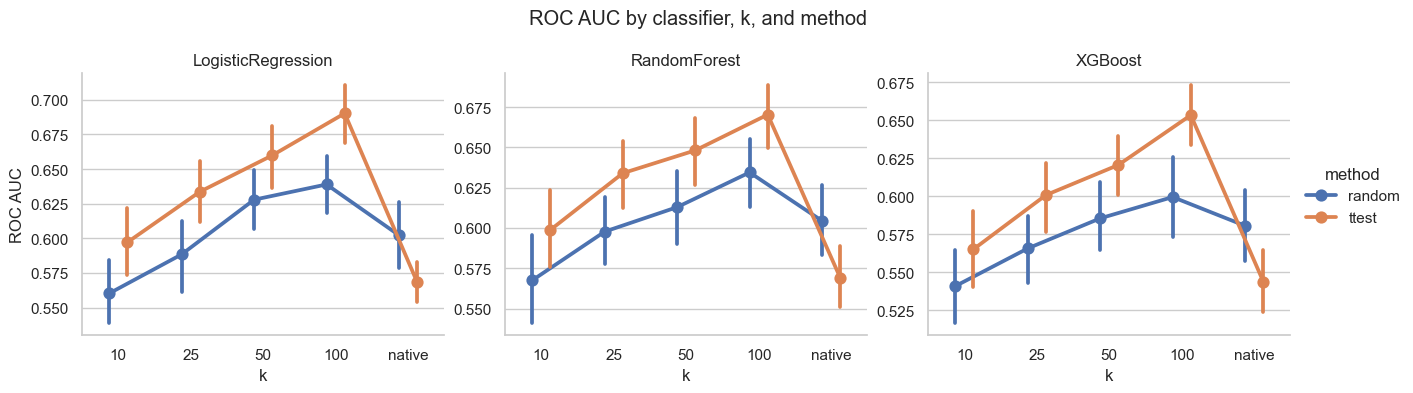

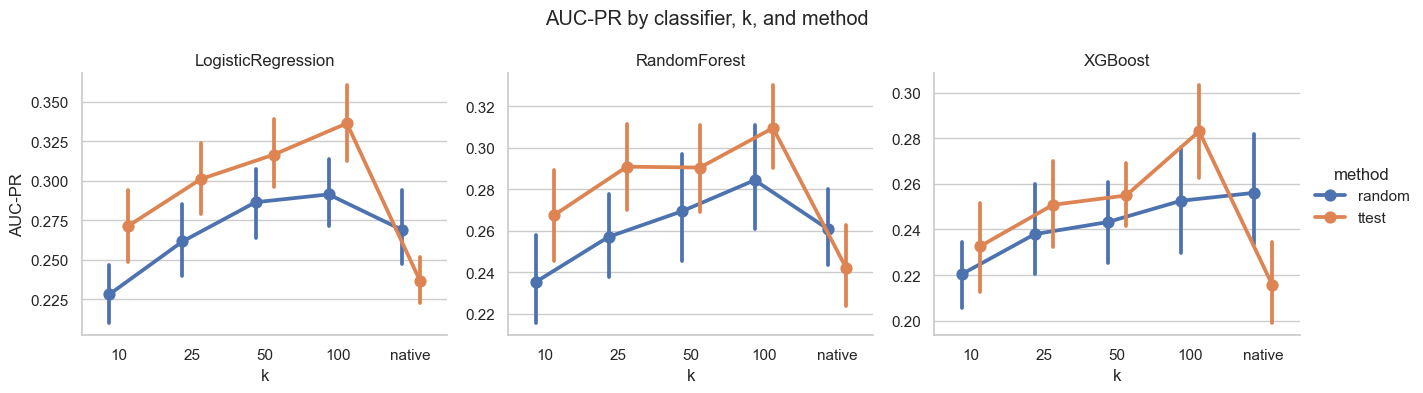

In [5]:
plot_df = scores.copy()

for metric, title in [("auc", "ROC AUC"), ("aupr", "AUC-PR")]:
    g = sns.catplot(
        data=plot_df,
        x="k",
        y=metric,
        hue="method",
        col="classifier",
        kind="point",
        estimator=np.nanmean,
        errorbar=("ci", 95),
        dodge=0.25,
        height=4,
        aspect=1.1,
        sharey=False,
    )
    g.set_axis_labels("k", title)
    g.set_titles("{col_name}")
    g.fig.subplots_adjust(top=0.82)
    g.fig.suptitle(f"{title} by classifier, k, and method")
    plt.show()

In [6]:
issues = scores[(scores["auc"].isna()) | (scores["aupr"].isna()) | (scores["n_features_actual"] == 0)].copy()

print(f"Rows with NaN metric or zero features: {len(issues):,} / {len(scores):,}")
if len(issues) > 0:
    issue_summary = (
        issues.groupby(["method", "classifier", "k"], observed=True, as_index=False)
        .agg(n_rows=("split_id", "size"))
        .sort_values("n_rows", ascending=False)
    )
    display(issue_summary)
else:
    print("No issues detected in metrics or feature counts.")

Rows with NaN metric or zero features: 24 / 1,500


,method,classifier,k,n_rows
0,ttest,LogisticRegression,native,8
1,ttest,RandomForest,native,8
2,ttest,XGBoost,native,8


In [7]:
def mean_table_for_k(k_value: str) -> pd.DataFrame:
    subset = scores[scores["k"] == k_value]
    return (
        subset.groupby(["method", "classifier"], observed=True, as_index=False)
        .agg(
            auc_mean=("auc", "mean"),
            aupr_mean=("aupr", "mean"),
            n_features_mean=("n_features_actual", "mean"),
        )
        .sort_values(["classifier", "auc_mean"], ascending=[True, False])
    )

print("Mean performance at k=50")
display(mean_table_for_k("50"))

print("Mean performance at native cutoff")
display(mean_table_for_k("native"))

Mean performance at k=50


,method,classifier,auc_mean,aupr_mean,n_features_mean
3,ttest,LogisticRegression,0.659822,0.316666,50.0
0,random,LogisticRegression,0.627848,0.286496,50.0
4,ttest,RandomForest,0.648172,0.290399,50.0
1,random,RandomForest,0.612932,0.269289,50.0
5,ttest,XGBoost,0.620491,0.254925,50.0
2,random,XGBoost,0.585440,0.243271,50.0


Mean performance at native cutoff


,method,classifier,auc_mean,aupr_mean,n_features_mean
0,random,LogisticRegression,0.602185,0.269093,30.00
3,ttest,LogisticRegression,0.568416,0.236809,18.16
1,random,RandomForest,0.604392,0.260813,30.00
4,ttest,RandomForest,0.569119,0.242053,18.16
2,random,XGBoost,0.580535,0.256092,30.00
5,ttest,XGBoost,0.543930,0.215719,18.16


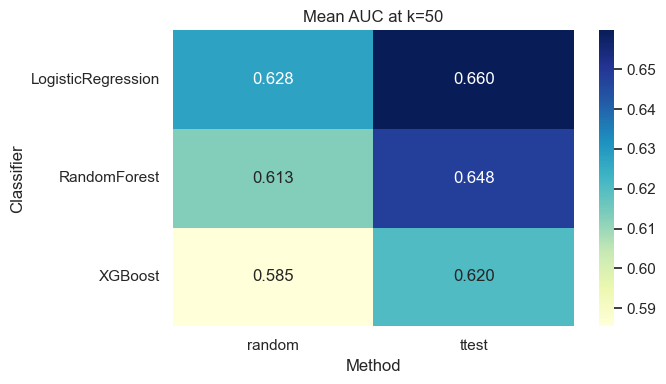

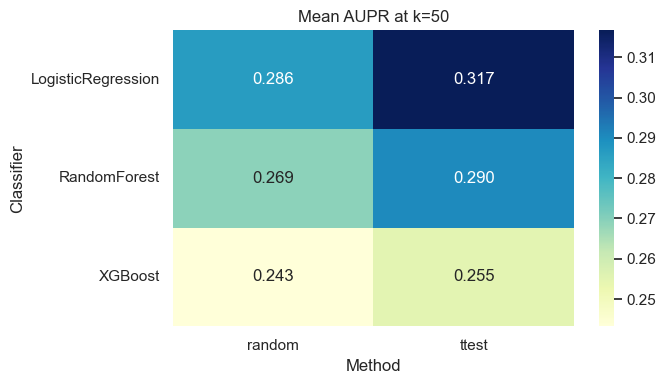

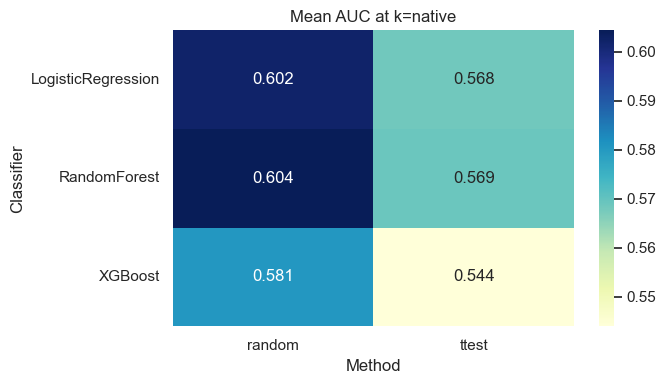

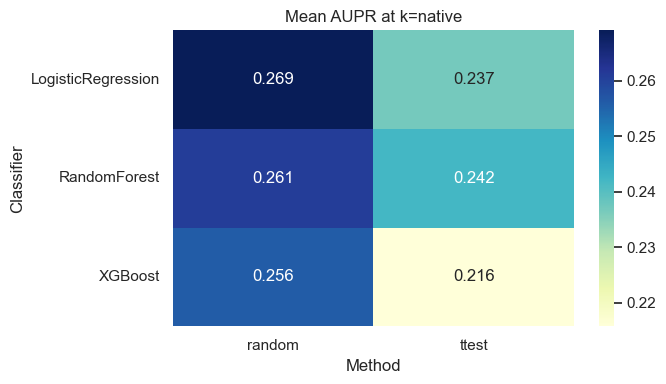

In [8]:
for metric, k_value in [("auc", "50"), ("aupr", "50"), ("auc", "native"), ("aupr", "native")]:
    heat = (
        scores[scores["k"] == k_value]
        .groupby(["classifier", "method"], observed=True)[metric]
        .mean()
        .unstack("method")
    )

    plt.figure(figsize=(7, 4))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title(f"Mean {metric.upper()} at k={k_value}")
    plt.xlabel("Method")
    plt.ylabel("Classifier")
    plt.tight_layout()
    plt.show()